<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/13_lstm_final_noleak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB13 — Comparação LSTM com os conjuntos de features do NB11

## 1. Papel do notebook

O NB13 avalia uma arquitetura LSTM como experimento complementar ao núcleo tabular consolidado no NB11. A finalidade não é deslocar o eixo metodológico da dissertação para redes neurais, mas verificar empiricamente se uma formulação sequencial recorrente consegue superar, de forma relevante, o melhor modelo tabular já selecionado.

A decisão central permanece condicionada ao critério quantitativo definido no pipeline:

\[
F1_{LSTM,TSCV} \geq F1_{NB11,TSCV} + 0{,}03
\]

Se esse critério não for atendido, os escores do NB11 permanecem como entrada preferencial do NB14.

## 2. Ajuste metodológico desta versão

Esta versão do NB13 incorpora a atualização narrativa decorrente da versão atual do NB11, que passou a incluir o baseline temporal suavizado por EWMA causal (`ewma_fail_rate_m2s_train`). O EWMA não altera a arquitetura da LSTM, não entra como feature e não se torna política decisória principal. Ele é usado apenas como referência comparativa adicional na interpretação dos resultados.

Com isso, o NB13 passa a situar a LSTM em três níveis de comparação:

1. regras temporais simples avaliadas no NB11;
2. EWMA causal como baseline temporal suavizado e interpretável;
3. LSTM como modelo sequencial não trivial.

Essa distinção é importante para a dissertação porque evita uma comparação binária simplista entre LSTM e Regressão Logística. A pergunta passa a ser mais precisa: a complexidade sequencial adicional da LSTM traz ganho suficiente em relação ao modelo tabular vencedor e também em relação aos baselines temporais causais já avaliados?

## 3. Relação com NB10, NB11 e NB12

O NB10 definiu o cenário principal da etapa dissertativa: `W5_K24_H12_P1_TRAIN_M2S`, com limiar causal estimado exclusivamente sobre o trecho de treino. O NB11 avaliou baselines temporais, modelos supervisionados tabulares, calibração e lead time, selecionando a Regressão Logística com `temporal_core` como referência principal. O NB12 confirmou a robustez dessa escolha e manteve `train_m2s` como cenário principal, deixando `train_p95` como sensibilidade forte, mas insuficiente para substituir a decisão central.

Dessa forma, o NB13 não reabre a escolha de limiar, não incorpora `train_p95` como novo cenário principal e não executa nova busca ampla de cenários. Ele apenas avalia se a LSTM, usando os artefatos e os conjuntos de features do NB11, justificaria substituir os escores do NB11 como entrada do NB14.

## 4. Mudança em relação à versão anterior do NB13

A versão anterior do NB13 lia diretamente o artefato do NB10 (`10_scenario_series_states.parquet`) e, por isso, executou a LSTM apenas com as features disponíveis naquele estágio. Isso resultava em uma comparação incompleta, pois as features temporais causais usadas pelo NB11 ainda não estavam materializadas naquele arquivo.

Nesta versão, o NB13 consome os artefatos materializados pelo NB11:

- `11_sequence_input_features.parquet`;
- `11_model_input_features.parquet`;
- `11_feature_sets.json`;
- `11_model_input_features_schema.json`;
- `11_nb11_summary.json`;
- `11_winner_model.json`;
- `11_baselines_summary.csv`, quando disponível.

Essa alteração torna a comparação mais justa: a LSTM passa a ser avaliada com os mesmos conjuntos de features formalizados no NB11, especialmente `raw_7` e `temporal_core`.

## 5. Diferença entre os artefatos de entrada do NB11

O arquivo `11_model_input_features.parquet` representa a matriz supervisionada usada pelo NB11 para modelagem tabular. Ele é adequado para auditoria, rastreabilidade e conferência do que foi efetivamente usado na etapa tabular.

O arquivo `11_sequence_input_features.parquet` preserva a continuidade temporal necessária para a LSTM. Por isso, é a entrada preferencial do NB13. As sequências são construídas sobre a série contínua e a elegibilidade supervisionada é aplicada apenas ao ponto final da sequência.

Essa estratégia evita a criação de sequências artificiais formadas por linhas não contíguas.

## 6. Controle de vazamento de informação

O NB13 mantém controle explícito de vazamento de informação. Não podem ser usadas como features:

- variáveis-alvo (`y`, `y_nb11`, `y_nb13`, `target`, `label`);
- estados operacionais ou indicadores derivados de estado;
- flags de criticidade;
- campos de horizonte, persistência, limiar ou cenário;
- campos de elegibilidade;
- identificadores;
- tempo absoluto;
- scores, probabilidades, predições, folds ou splits gerados por modelos anteriores.

A coluna de elegibilidade, quando presente, é usada apenas para selecionar pontos finais válidos para a tarefa supervisionada. Ela nunca é fornecida como entrada da LSTM.

## 7. Escopo de cenários

Para evitar explosão computacional, o NB13 não executa todos os cenários por padrão.

O escopo padrão é:

```text
nb11_main_plus_10min
```

Isso significa avaliar:

1. o cenário vencedor do NB11;
2. um cenário análogo de 10 minutos, quando disponível.

Também são previstas opções para executar apenas o cenário principal ou todos os cenários materializados pelo NB11, mas essas opções devem ser usadas apenas quando houver necessidade específica e tempo computacional suficiente.

## 8. Conjuntos de features avaliados

O notebook avalia, quando disponíveis:

- `raw_7`;
- `temporal_core`.

O conjunto `raw_7` corresponde às variáveis brutas principais. O conjunto `temporal_core` acrescenta defasagens, estatísticas móveis, variação percentual e z-score causal.

O conjunto `temporal_full` é carregado quando existir, mas não é executado por padrão, para evitar ampliar desnecessariamente o custo computacional e a complexidade interpretativa do NB13.

## 9. Tratamento do EWMA no NB13

O EWMA causal é tratado como baseline comparativo herdado do NB11. O NB13 tenta ler `11_baselines_summary.csv` para registrar, no `13_lstm_summary.json`, a posição do EWMA em relação ao melhor baseline e ao modelo supervisionado vencedor.

O EWMA não é usado como entrada da LSTM. Também não é usado como escore decisório no NB14. Para que o EWMA fosse usado diretamente na função de custo \(C(\tau)\), seria necessário exportar uma série pontuada por janela ou uma política de alerta específica, o que abriria uma ramificação metodológica adicional. Esta versão evita essa expansão.

## 10. Artefatos esperados

O NB13 gera artefatos diretamente em `04-reports/`, com nomes canônicos e sem sufixos adicionais:

- `13_lstm_fixed_results.csv`;
- `13_lstm_tscv_results.csv`;
- `13_lstm_fixed_results_agg.csv`;
- `13_lstm_tscv_results_agg.csv`;
- `13_lstm_scores.parquet` ou `13_lstm_scores.csv`;
- `13_lstm_feature_columns.json`;
- `13_lstm_baseline_context.json`;
- `13_lstm_summary.json`;
- `13_lstm_conclusion.txt`.

As figuras diagnósticas são salvas em:

```text
04-reports/figures_nb13_lstm/
```

## 11. Critério de decisão para NB14

A LSTM só deve substituir os escores do NB11 como entrada do NB14 se superar o F1 médio TSCV do vencedor do NB11 em pelo menos 0,03.

Caso contrário, o NB13 deve registrar a LSTM como experimento complementar defensivo, mantendo os escores do NB11 como base para a análise de limiar, custo assimétrico e classes de decisão no NB14.

## 12. Resultado esperado do notebook

Ao final da execução, o NB13 deve responder objetivamente:

1. a LSTM superou o modelo tabular vencedor do NB11 por margem suficiente?
2. a LSTM trouxe ganho metodológico claro em relação ao conjunto de baselines temporais, incluindo o EWMA causal?
3. os escores da LSTM devem ou não alimentar o NB14?
4. quais artefatos foram gerados para rastreabilidade e consolidação no NB16?

A expectativa metodológica inicial é conservadora: a LSTM é útil como comparação temporal não trivial, mas somente deve deslocar o núcleo tabular se apresentar ganho claro, estável e compatível com o critério quantitativo definido.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[2026-05-26 16:58:36] ====================================================================================================
[2026-05-26 16:58:36] NB13 — Comparação LSTM com os conjuntos de features do NB11
[2026-05-26 16:58:36] RUN_TIMESTAMP = 2026-05-26 16:58:34
[2026-05-26 16:58:36] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-05-26 16:58:36] REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[2026-05-26 16:58:36] FIGURES_PATH = /content/drive/MyDrive/Mestrado/04-reports/figures_nb13_lstm
[2026-05-26 16:58:36] ====================================================================================================
[2026-05-26 16:58:36] CONFIG:
{
  "run_mode": "FINAL_LIGHT",
  "scenario_scope": "nb11_main_plus_10min",
  "feature_sets_to_evaluate": [
    "raw_7",
    "temporal_core"
  ],
  "sequence_length": 24,
  "min_delta_f1_to_feed_nb14": 0.03,
  "cl

,scenario_label,feature_set,protocol,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
4,W5_K24_H12_P1_TRAIN_M2S,raw_7,fixed_80_20,8,0.765876,0.005766,0.782354,0.006538,0.935859,0.022212,...,0.721064,0.0,14.666667,0.577350,0.600367,0.007143,10.905957,0.469629,11.412794,0.648135
6,W5_K24_H12_P1_TRAIN_M2S,temporal_core,fixed_80_20,8,0.768751,0.012228,0.798864,0.019294,0.908940,0.019083,...,0.721064,0.0,13.000000,1.000000,0.593137,0.004668,11.012335,0.700367,11.409749,0.707984
7,W5_K24_H12_P1_TRAIN_M2S,temporal_core,fixed_80_20,16,0.764198,0.009346,0.803941,0.009760,0.890329,0.019022,...,0.721064,0.0,12.000000,1.000000,0.584945,0.007222,10.597550,0.317613,11.025749,0.346438
5,W5_K24_H12_P1_TRAIN_M2S,raw_7,fixed_80_20,16,0.753654,0.006833,0.793490,0.010640,0.890329,0.013413,...,0.721064,0.0,12.000000,1.000000,0.588273,0.002893,11.376789,0.738399,11.776314,0.732047
3,W10_K12_H6_P1_TRAIN_M2S,temporal_core,fixed_80_20,16,0.729594,0.004179,0.690774,0.005998,0.913952,0.023287,...,0.545828,0.0,12.666667,1.154701,0.633153,0.008775,9.573231,1.292576,9.959807,1.304721
2,W10_K12_H6_P1_TRAIN_M2S,temporal_core,fixed_80_20,8,0.709074,0.036305,0.665600,0.036931,0.947368,0.026405,...,0.545828,0.0,12.333333,3.055050,0.654571,0.006891,7.641416,0.749602,8.254852,0.767060
1,W10_K12_H6_P1_TRAIN_M2S,raw_7,fixed_80_20,16,0.697674,0.021369,0.659036,0.021830,0.927318,0.013023,...,0.545828,0.0,11.666667,1.527525,0.648593,0.007878,6.777329,0.643827,7.155701,0.627143
0,W10_K12_H6_P1_TRAIN_M2S,raw_7,fixed_80_20,8,0.670315,0.038377,0.631162,0.035511,0.965748,0.038366,...,0.545828,0.0,13.000000,1.732051,0.683531,0.012083,6.935526,0.511534,7.306743,0.518252


[2026-05-26 17:40:57] Resultados agregados TSCV:


,scenario_label,feature_set,protocol,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
6,W5_K24_H12_P1_TRAIN_M2S,temporal_core,tscv,8,0.595513,0.156389,0.475497,0.279092,0.729598,0.213295,...,0.433477,0.237262,24.000000,15.142183,0.608276,0.054898,12.609612,5.701763,13.022916,5.693432
4,W5_K24_H12_P1_TRAIN_M2S,raw_7,tscv,8,0.631176,0.121241,0.473258,0.271043,0.700633,0.275418,...,0.433477,0.237262,28.200000,15.776112,0.585250,0.061564,14.409458,6.000524,14.847879,5.989925
7,W5_K24_H12_P1_TRAIN_M2S,temporal_core,tscv,16,0.608916,0.144025,0.469057,0.282565,0.698943,0.259544,...,0.433477,0.237262,21.200000,12.717817,0.596492,0.056426,12.172091,5.073215,12.589454,5.073338
5,W5_K24_H12_P1_TRAIN_M2S,raw_7,tscv,16,0.623066,0.120178,0.469185,0.279471,0.675658,0.272841,...,0.433477,0.237262,22.733333,14.355022,0.578952,0.062239,12.585246,5.843936,13.030529,5.832982
1,W10_K12_H6_P1_TRAIN_M2S,raw_7,tscv,16,0.595175,0.114336,0.337817,0.232655,0.695279,0.247884,...,0.265789,0.181408,22.200000,17.259366,0.591704,0.151362,9.777828,4.951504,10.212313,4.965786
0,W10_K12_H6_P1_TRAIN_M2S,raw_7,tscv,8,0.607456,0.110844,0.329762,0.219118,0.701766,0.277730,...,0.265789,0.181408,25.266667,17.798341,0.603694,0.140247,10.120778,5.352245,10.553253,5.361337
3,W10_K12_H6_P1_TRAIN_M2S,temporal_core,tscv,16,0.660746,0.121124,0.343639,0.254442,0.513302,0.299451,...,0.265789,0.181408,28.533333,19.708108,0.550140,0.146975,10.626996,4.970095,11.045621,4.933325
2,W10_K12_H6_P1_TRAIN_M2S,temporal_core,tscv,8,0.589145,0.108462,0.309365,0.269817,0.602402,0.339733,...,0.265789,0.181408,26.466667,19.956620,0.603202,0.131364,9.794407,4.897580,10.246917,4.847855


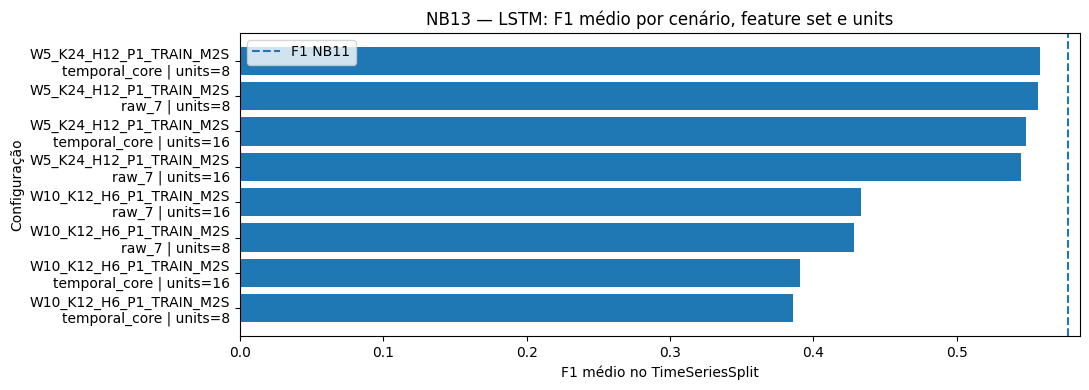

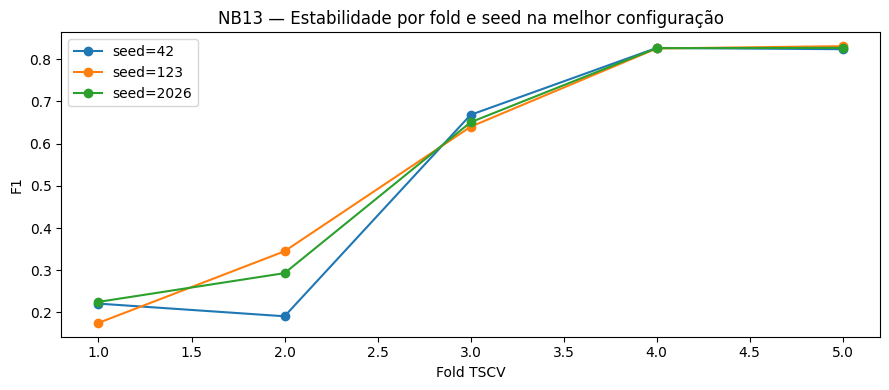

[2026-05-26 17:40:58] ====================================================================================================
[2026-05-26 17:40:58] FIM DO NB13 — Comparação LSTM com conjuntos do NB11
[2026-05-26 17:40:58] Tempo total: 42.32 min
[2026-05-26 17:40:58] fixed_results: (24, 29)
[2026-05-26 17:40:58] tscv_results: (120, 29)
[2026-05-26 17:40:58] scores_df: (131484, 12)
[2026-05-26 17:40:58] Melhor F1 TSCV LSTM: 0.5579689978151948
[2026-05-26 17:40:58] Melhor F1 TSCV NB11: 0.5773731424098736
[2026-05-26 17:40:58] Delta LSTM - NB11: -0.019404144594678763
[2026-05-26 17:40:58] Decisão NB14: keep_nb11_scores_for_nb14
[2026-05-26 17:40:58] ====================================================================================================

Artefatos salvos:
- fixed_results: /content/drive/MyDrive/Mestrado/04-reports/13_lstm_fixed_results.csv
- tscv_results: /content/drive/MyDrive/Mestrado/04-reports/13_lstm_tscv_results.csv
- fixed_results_agg: /content/drive/MyDrive/Mestrado/04-rep

,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,seed,units,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1391,1003,0.721064,0.5,0.771387,0.781893,0.947159,0.856628,0.743491,0.845524,...,42,8,7,24,14,0.599667,0.622862,10.602689,11.007897,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
1,1391,1003,0.721064,0.5,0.759885,0.789110,0.910269,0.845370,0.744532,0.857960,...,123,8,7,24,15,0.593601,0.609655,10.668267,11.070152,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
2,1391,1003,0.721064,0.5,0.766355,0.776059,0.950150,0.854325,0.756866,0.865108,...,2026,8,7,24,15,0.607835,0.621114,11.446914,12.160331,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
3,1391,1003,0.721064,0.5,0.760604,0.798043,0.894317,0.843441,0.737167,0.854480,...,42,16,7,24,12,0.589275,0.646915,11.972100,12.366795,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
4,1391,1003,0.721064,0.5,0.753415,0.801095,0.875374,0.836589,0.752076,0.870182,...,123,16,7,24,11,0.585012,0.642502,10.550516,10.957249,"{0: 0.6399194708081679, 1: 2.2867420349434737}"



Amostra tscv_results:


,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,seed,units,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1159,240,0.207075,0.5,0.400345,0.133655,0.345833,0.192799,0.336820,0.152310,...,42,8,7,24,29,0.557514,0.570358,11.311495,11.699458,"{0: 0.5346020761245674, 1: 7.725}"
1,1159,240,0.207075,0.5,0.437446,0.141115,0.337500,0.199017,0.368902,0.165667,...,123,8,7,24,37,0.526050,0.555758,11.639987,12.027820,"{0: 0.5346020761245674, 1: 7.725}"
2,1159,240,0.207075,0.5,0.470233,0.131890,0.279167,0.179144,0.372148,0.155522,...,2026,8,7,24,47,0.564168,0.570200,15.372718,15.766602,"{0: 0.5346020761245674, 1: 7.725}"
3,1159,240,0.207075,0.5,0.415013,0.126280,0.308333,0.179177,0.331198,0.146967,...,42,16,7,24,26,0.552727,0.593995,10.476011,10.876508,"{0: 0.5346020761245674, 1: 7.725}"
4,1159,240,0.207075,0.5,0.411562,0.136513,0.345833,0.195755,0.352757,0.157017,...,123,16,7,24,27,0.529923,0.568004,10.321381,10.707402,"{0: 0.5346020761245674, 1: 7.725}"


In [4]:

# ============================================================
# NB13 — Comparação LSTM com os conjuntos de features do NB11
# Código completo ajustado — versão com contexto EWMA do NB11
# ============================================================

import os
import re
import gc
import json
import math
import time
import shutil
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0. TensorFlow / Keras
# ------------------------------------------------------------

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
except Exception as exc:
    TENSORFLOW_AVAILABLE = False
    TF_IMPORT_ERROR = repr(exc)

if not TENSORFLOW_AVAILABLE:
    raise ImportError(
        "TensorFlow/Keras não está disponível neste ambiente. "
        f"Erro original: {TF_IMPORT_ERROR}"
    )

# ------------------------------------------------------------
# 1. Log, utilidades e diretórios
# ------------------------------------------------------------

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def log(msg):
    print(f"[{now_str()}] {msg}", flush=True)

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def safe_load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_json_dump(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

FEATURES_PATH = ensure_dir(BASE_DIR / "02-datasets" / "03-features")
MODELS_PATH = ensure_dir(BASE_DIR / "03-models")
REPORTS_PATH = ensure_dir(BASE_DIR / "04-reports")
FIGURES_PATH = ensure_dir(REPORTS_PATH / "figures_nb13_lstm")
BACKUP_BASE_PATH = ensure_dir(REPORTS_PATH / "_backup_previous_artifacts")

log("=" * 100)
log("NB13 — Comparação LSTM com os conjuntos de features do NB11")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_PATH = {REPORTS_PATH}")
log(f"FIGURES_PATH = {FIGURES_PATH}")
log("=" * 100)

# ------------------------------------------------------------
# 2. Configuração
# ------------------------------------------------------------

# RUN_MODE:
# - "SMOKE": teste rápido de ponta a ponta.
# - "FINAL_LIGHT": execução recomendada.
# - "FULL": execução ampliada.
RUN_MODE = "FINAL_LIGHT"

CONFIG = {
    "run_mode": RUN_MODE,

    # Escopo de cenários:
    # - "nb11_main_only": apenas o cenário vencedor do NB11.
    # - "nb11_main_plus_10min": cenário vencedor + cenário análogo de 10 min, se disponível.
    # - "all_nb11_scenarios": todos os cenários disponíveis no arquivo sequencial.
    "scenario_scope": "nb11_main_plus_10min",

    # Feature sets a avaliar.
    "feature_sets_to_evaluate": ["raw_7", "temporal_core"],

    # Sequência LSTM.
    "sequence_length": 24,

    # Critério de decisão para NB14.
    "min_delta_f1_to_feed_nb14": 0.03,
    "classification_threshold": 0.50,

    # Protocolo temporal.
    "fixed_train_fraction": 0.80,
    "validation_fraction_from_train": 0.20,

    # Controle.
    "save_keras_models": False,
    "keras_verbose": 0,
    "backup_previous_outputs": True,

    # Leitura do NB11.
    "prefer_reports_root": True,
    "allow_legacy_nb11_subdir_fallback": True,
}

if RUN_MODE == "SMOKE":
    CONFIG.update({
        "lstm_units_grid": [8],
        "seeds": [42],
        "tscv_splits": 2,
        "max_epochs": 10,
        "batch_size": 128,
        "early_stopping_patience": 3,
        "reduce_lr_patience": 2,
        "scenario_scope": "nb11_main_only",
        "feature_sets_to_evaluate": ["raw_7"],
        "keras_verbose": 1,
    })
elif RUN_MODE == "FINAL_LIGHT":
    CONFIG.update({
        "lstm_units_grid": [8, 16],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 50,
        "batch_size": 128,
        "early_stopping_patience": 8,
        "reduce_lr_patience": 4,
        "dropout": 0.20,
        "learning_rate": 1e-3,
    })
elif RUN_MODE == "FULL":
    CONFIG.update({
        "lstm_units_grid": [8, 16, 32],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 100,
        "batch_size": 128,
        "early_stopping_patience": 12,
        "reduce_lr_patience": 5,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "scenario_scope": "all_nb11_scenarios",
    })
else:
    raise ValueError(f"RUN_MODE inválido: {RUN_MODE}")

log("CONFIG:")
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

# ------------------------------------------------------------
# 3. Localização de artefatos do NB11
# ------------------------------------------------------------

def find_file(filename, required=True):
    candidates = []

    if CONFIG.get("prefer_reports_root", True):
        candidates.append(REPORTS_PATH / filename)

    if CONFIG.get("allow_legacy_nb11_subdir_fallback", True):
        candidates.append(REPORTS_PATH / "nb11" / filename)

    candidates.append(BASE_DIR / filename)

    for p in candidates:
        if Path(p).exists():
            return Path(p)

    if required:
        msg = "Arquivo obrigatório não encontrado: " + filename + "\nCandidatos:\n"
        msg += "\n".join(str(c) for c in candidates)
        raise FileNotFoundError(msg)

    return None

PATH_SEQUENCE_INPUT = find_file("11_sequence_input_features.parquet", required=True)
PATH_MODEL_INPUT = find_file("11_model_input_features.parquet", required=True)
PATH_FEATURE_SETS = find_file("11_feature_sets.json", required=True)
PATH_SCHEMA = find_file("11_model_input_features_schema.json", required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", required=True)
PATH_WINNER_MODEL = find_file("11_winner_model.json", required=False)
PATH_BASELINES_SUMMARY = find_file("11_baselines_summary.csv", required=False)

log("Artefatos NB11 localizados:")
for name, path in {
    "sequence_input": PATH_SEQUENCE_INPUT,
    "model_input": PATH_MODEL_INPUT,
    "feature_sets": PATH_FEATURE_SETS,
    "schema": PATH_SCHEMA,
    "nb11_summary": PATH_NB11_SUMMARY,
    "winner_model": PATH_WINNER_MODEL,
    "baselines_summary": PATH_BASELINES_SUMMARY,
}.items():
    log(f"{name}: {path}")

feature_sets_json = safe_load_json(PATH_FEATURE_SETS)
schema_json = safe_load_json(PATH_SCHEMA)
nb11_summary = safe_load_json(PATH_NB11_SUMMARY)
winner_model = safe_load_json(PATH_WINNER_MODEL) if PATH_WINNER_MODEL else nb11_summary.get("winner", {})

# ------------------------------------------------------------
# 3.1. Contexto dos baselines temporais do NB11, incluindo EWMA
#      Versão corrigida: prioriza TSCV do cenário principal
# ------------------------------------------------------------

def _find_col(df, candidates):
    """Retorna a primeira coluna existente entre os nomes candidatos, com comparação case-insensitive."""
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = str(cand).strip().lower()
        if key in lower_map:
            return lower_map[key]
    return None

def _safe_float_value(row, col):
    """Converte valor de uma linha/dict em float, retornando None quando ausente ou inválido."""
    if row is None or col is None:
        return None
    try:
        value = row.get(col) if hasattr(row, "get") else row[col]
    except Exception:
        return None
    try:
        if pd.isna(value):
            return None
        return float(value)
    except Exception:
        return None

def _jsonable_row(row):
    """Converte linha pandas/dict em estrutura serializável em JSON."""
    if row is None:
        return None
    if hasattr(row, "to_dict"):
        row = row.to_dict()
    out = {}
    for k, v in row.items():
        try:
            if pd.isna(v):
                out[k] = None
            elif isinstance(v, (np.integer,)):
                out[k] = int(v)
            elif isinstance(v, (np.floating,)):
                out[k] = float(v)
            else:
                out[k] = v
        except Exception:
            out[k] = str(v)
    return out

def _metrics_from_row(row, cols):
    """Extrai métricas padronizadas a partir de uma linha e do mapa de colunas detectadas."""
    return {
        "f1": _safe_float_value(row, cols.get("f1")),
        "recall": _safe_float_value(row, cols.get("recall")),
        "precision": _safe_float_value(row, cols.get("precision")),
        "roc_auc": _safe_float_value(row, cols.get("roc_auc")),
        "average_precision": _safe_float_value(row, cols.get("average_precision")),
        "brier": _safe_float_value(row, cols.get("brier")),
        "false_alerts_per_day": _safe_float_value(row, cols.get("false_alerts_per_day")),
    }

def _normalize_protocol(series):
    """Normaliza rótulos de validação/protocolo para filtragem robusta."""
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )

def _main_scenario_from_nb11(nb11_summary_dict):
    """Obtém o cenário principal do NB11, com fallback explícito."""
    fallback = "W5_K24_H12_P1_TRAIN_M2S"
    if not isinstance(nb11_summary_dict, dict):
        return fallback

    candidates = [
        nb11_summary_dict.get("scenario_label"),
        nb11_summary_dict.get("main_scenario"),
        nb11_summary_dict.get("winner_scenario"),
    ]

    for nested_key in ["winner", "winner_model", "nb11_reference", "best_model"]:
        nested = nb11_summary_dict.get(nested_key)
        if isinstance(nested, dict):
            candidates.extend([
                nested.get("scenario_label"),
                nested.get("scenario"),
                nested.get("scenario_name"),
            ])

    for value in candidates:
        if isinstance(value, str) and value.strip():
            return value.strip()

    return fallback

def extract_nb11_baseline_context(path_baselines_summary, nb11_summary_dict):
    """
    Lê o resumo de baselines do NB11 e extrai contexto comparativo para o NB13.

    Correção central desta versão:
    - detecta a coluna 'validation', além de 'protocol' e equivalentes;
    - filtra primeiro o cenário principal do NB11;
    - prioriza o EWMA no TimeSeriesSplit;
    - preserva o corte fixo 80/20 apenas como complemento;
    - evita rotular como TSCV uma linha fixed_80_20 de outro cenário.
    """
    main_scenario = _main_scenario_from_nb11(nb11_summary_dict)

    context = {
        "available": False,
        "source": str(path_baselines_summary) if path_baselines_summary else None,
        "main_scenario": main_scenario,
        "preferred_protocol_for_narrative": "TimeSeriesSplit",
        "ewma_available": False,
        "ewma_main_tscv_available": False,
        "ewma_main_fixed_available": False,
        "ewma_main_tscv_row": None,
        "ewma_main_fixed_row": None,
        "ewma_main_tscv_metrics": None,
        "ewma_main_fixed_metrics": None,
        "best_baseline_main_tscv": None,
        "best_baseline_main_tscv_metrics": None,
        "best_baseline_overall_tscv": None,
        "best_baseline_overall_tscv_metrics": None,
        # Campos legados mantidos para compatibilidade com partes antigas do notebook.
        "ewma_row": None,
        "ewma_metrics": None,
        "best_baseline_tscv": None,
        "best_baseline_metrics": None,
        "notes": [
            "O EWMA é tratado como baseline comparativo herdado do NB11.",
            "O EWMA não é usado como feature da LSTM.",
            "O EWMA não substitui os escores do modelo vencedor do NB11 na cadeia NB14.",
            "A narrativa principal deve usar o EWMA do cenário principal no TimeSeriesSplit, quando disponível.",
        ],
    }

    if path_baselines_summary is None or not Path(path_baselines_summary).exists():
        context["notes"].append("Arquivo 11_baselines_summary.csv não encontrado; contexto EWMA será registrado apenas de forma descritiva.")
        return context

    try:
        dfb = pd.read_csv(path_baselines_summary)
    except Exception as exc:
        context["notes"].append(f"Falha ao ler 11_baselines_summary.csv: {exc}")
        return context

    context["available"] = True
    context["shape"] = list(dfb.shape)
    context["columns"] = list(dfb.columns)

    baseline_col = _find_col(dfb, ["baseline", "model", "model_name", "method", "name"])
    # Correção: incluir explicitamente 'validation', que é a coluna observada no 11_baselines_summary.csv.
    protocol_col = _find_col(dfb, ["validation", "protocol", "validation_protocol", "split", "evaluation_protocol"])
    scenario_col = _find_col(dfb, ["scenario_label", "scenario", "cenario"])
    f1_col = _find_col(dfb, ["f1_mean", "f1", "mean_f1"])
    recall_col = _find_col(dfb, ["recall_mean", "recall", "mean_recall"])
    precision_col = _find_col(dfb, ["precision_mean", "precision", "mean_precision"])
    roc_auc_col = _find_col(dfb, ["roc_auc_mean", "roc_auc", "auc_mean"])
    avg_precision_col = _find_col(dfb, ["average_precision_mean", "avg_precision_mean", "average_precision", "avg_precision"])
    brier_col = _find_col(dfb, ["brier_mean", "brier", "brier_score"])
    false_alerts_col = _find_col(dfb, ["false_alerts_per_day_mean", "false_alerts_per_day"])

    cols = {
        "baseline": baseline_col,
        "protocol": protocol_col,
        "scenario": scenario_col,
        "f1": f1_col,
        "recall": recall_col,
        "precision": precision_col,
        "roc_auc": roc_auc_col,
        "average_precision": avg_precision_col,
        "brier": brier_col,
        "false_alerts_per_day": false_alerts_col,
    }
    context["detected_columns"] = cols

    required = [baseline_col, scenario_col, f1_col]
    if any(c is None for c in required):
        context["notes"].append(
            "Colunas mínimas não detectadas em 11_baselines_summary.csv; "
            "não foi possível extrair contexto EWMA com segurança."
        )
        return context

    df_work = dfb.copy()
    df_work["_baseline_norm"] = df_work[baseline_col].astype(str).str.strip().str.lower()
    df_work["_scenario_norm"] = df_work[scenario_col].astype(str).str.strip()

    if protocol_col:
        df_work["_validation_norm"] = _normalize_protocol(df_work[protocol_col])
    else:
        df_work["_validation_norm"] = "unknown"
        context["notes"].append(
            "Coluna de validação/protocolo não detectada; não é possível separar TSCV de corte fixo com segurança."
        )

    main_mask = df_work["_scenario_norm"].eq(main_scenario)
    ewma_mask = df_work["_baseline_norm"].str.contains("ewma", na=False)
    tscv_mask = df_work["_validation_norm"].str.contains("tscv|time_series|timeseries|time", regex=True, na=False)
    fixed_mask = df_work["_validation_norm"].str.contains("fixed|80_20|8020|holdout", regex=True, na=False)

    df_main = df_work.loc[main_mask].copy()
    df_main_tscv = df_work.loc[main_mask & tscv_mask].copy()
    df_overall_tscv = df_work.loc[tscv_mask].copy()

    # EWMA do cenário principal no TSCV: referência narrativa preferencial.
    ewma_main_tscv = df_work.loc[main_mask & ewma_mask & tscv_mask].copy()
    if not ewma_main_tscv.empty:
        if f1_col:
            ewma_main_tscv = ewma_main_tscv.sort_values(f1_col, ascending=False)
        row = ewma_main_tscv.iloc[0]
        context["ewma_available"] = True
        context["ewma_main_tscv_available"] = True
        context["ewma_main_tscv_row"] = _jsonable_row(row)
        context["ewma_main_tscv_metrics"] = _metrics_from_row(row, cols)
        # Campos legados apontam para a referência correta.
        context["ewma_row"] = context["ewma_main_tscv_row"]
        context["ewma_metrics"] = context["ewma_main_tscv_metrics"]
    else:
        context["notes"].append(
            f"EWMA do cenário principal {main_scenario} não encontrado no TimeSeriesSplit em 11_baselines_summary.csv."
        )

    # EWMA do cenário principal no corte fixo: apenas complementar.
    ewma_main_fixed = df_work.loc[main_mask & ewma_mask & fixed_mask].copy()
    if not ewma_main_fixed.empty:
        if f1_col:
            ewma_main_fixed = ewma_main_fixed.sort_values(f1_col, ascending=False)
        row = ewma_main_fixed.iloc[0]
        context["ewma_available"] = True
        context["ewma_main_fixed_available"] = True
        context["ewma_main_fixed_row"] = _jsonable_row(row)
        context["ewma_main_fixed_metrics"] = _metrics_from_row(row, cols)

    # Fallback: se houver EWMA no cenário principal, mas sem TSCV detectável, registra melhor linha como complementar, sem chamá-la de TSCV.
    if not context["ewma_main_tscv_available"]:
        ewma_main_any = df_work.loc[main_mask & ewma_mask].copy()
        if not ewma_main_any.empty:
            if f1_col:
                ewma_main_any = ewma_main_any.sort_values(f1_col, ascending=False)
            row = ewma_main_any.iloc[0]
            context["ewma_available"] = True
            context["ewma_main_any_row"] = _jsonable_row(row)
            context["ewma_main_any_metrics"] = _metrics_from_row(row, cols)
            context["notes"].append(
                "Há linha EWMA para o cenário principal, mas ela não foi classificada como TSCV; "
                "não usar seus valores como evidência temporal principal."
            )

    # Melhor baseline do cenário principal em TSCV.
    if f1_col and not df_main_tscv.empty:
        best_main = df_main_tscv.sort_values(f1_col, ascending=False).iloc[0]
        context["best_baseline_main_tscv"] = _jsonable_row(best_main)
        context["best_baseline_main_tscv_metrics"] = _metrics_from_row(best_main, cols)
        context["best_baseline_tscv"] = context["best_baseline_main_tscv"]
        context["best_baseline_metrics"] = {
            "name": best_main.get(baseline_col),
            **context["best_baseline_main_tscv_metrics"],
        }

    # Melhor baseline geral em TSCV, preservado para auditoria.
    if f1_col and not df_overall_tscv.empty:
        best_overall = df_overall_tscv.sort_values(f1_col, ascending=False).iloc[0]
        context["best_baseline_overall_tscv"] = _jsonable_row(best_overall)
        context["best_baseline_overall_tscv_metrics"] = _metrics_from_row(best_overall, cols)

    # Métricas consolidadas/fallback do NB12, usadas apenas se o CSV não trouxer a linha TSCV desejada.
    # Esses valores vieram da leitura consolidada do relatório NB12/NB11 e evitam repetir o erro fixed_80_20 como TSCV.
    if not context["ewma_main_tscv_available"]:
        context["ewma_main_tscv_metrics_fallback_nb12"] = {
            "f1": 0.246,
            "recall": 0.161,
            "precision": 0.786,
            "roc_auc": 0.549,
            "brier": 0.375,
        }
        context["notes"].append(
            "Fallback narrativo disponível: EWMA no TSCV do cenário principal conforme consolidação NB11/NB12 "
            "(F1=0,246; recall=0,161; precisão=0,786; ROC-AUC=0,549; Brier=0,375)."
        )

    context["interpretation"] = {
        "role": "baseline temporal suavizado herdado do NB11",
        "used_as_lstm_feature": False,
        "used_as_nb14_decision_score": False,
        "preferred_protocol_for_narrative": "TimeSeriesSplit",
        "fixed_split_role": "complementar apenas",
        "warning": (
            "Não rotular como TSCV uma linha fixed_80_20. "
            "A narrativa principal deve priorizar scenario_label=W5_K24_H12_P1_TRAIN_M2S e protocolo TimeSeriesSplit."
        ),
    }

    return context

def _format_metric(value, ndigits=4):
    if value is None:
        return "não disponível"
    try:
        if pd.isna(value):
            return "não disponível"
        return f"{float(value):.{ndigits}f}"
    except Exception:
        return str(value)

def make_ewma_conclusion_note(baseline_context, nb11_best_f1, best_lstm_f1):
    """Gera nota textual sem confundir corte fixo com TSCV."""
    parts = [
        "Contexto EWMA: o EWMA causal foi preservado como baseline temporal suavizado herdado do NB11.",
        "Ele não foi usado como feature da LSTM nem como escore decisório do NB14."
    ]

    if baseline_context.get("ewma_main_tscv_available"):
        metrics = baseline_context.get("ewma_main_tscv_metrics") or {}
        parts.append(
            "No cenário principal W5_K24_H12_P1_TRAIN_M2S, a linha EWMA do TimeSeriesSplit foi localizada em "
            "11_baselines_summary.csv. "
            f"Suas métricas são: F1={_format_metric(metrics.get('f1'))}, "
            f"recall={_format_metric(metrics.get('recall'))}, "
            f"precisão={_format_metric(metrics.get('precision'))}, "
            f"ROC-AUC={_format_metric(metrics.get('roc_auc'))} e "
            f"Brier={_format_metric(metrics.get('brier'))}."
        )
        ewma_f1 = metrics.get("f1")
    else:
        fallback = baseline_context.get("ewma_main_tscv_metrics_fallback_nb12") or {}
        if fallback:
            parts.append(
                "A linha EWMA do cenário principal no TimeSeriesSplit não foi localizada automaticamente no CSV, "
                "portanto a narrativa deve usar a referência consolidada do NB11/NB12: "
                f"F1={_format_metric(fallback.get('f1'), 3)}, "
                f"recall={_format_metric(fallback.get('recall'), 3)}, "
                f"precisão={_format_metric(fallback.get('precision'), 3)}, "
                f"ROC-AUC={_format_metric(fallback.get('roc_auc'), 3)} e "
                f"Brier={_format_metric(fallback.get('brier'), 3)}."
            )
            ewma_f1 = fallback.get("f1")
        else:
            parts.append(
                "Não foi possível localizar automaticamente as métricas TSCV do EWMA; "
                "assim, ele permanece apenas como referência comparativa descritiva."
            )
            ewma_f1 = None

    fixed_metrics = baseline_context.get("ewma_main_fixed_metrics")
    if fixed_metrics:
        parts.append(
            "O corte fixo 80/20, quando presente, deve ser tratado apenas como informação complementar "
            f"(F1={_format_metric(fixed_metrics.get('f1'))}), sem substituir a evidência TSCV."
        )

    if ewma_f1 is not None and best_lstm_f1 is not None and not np.isnan(best_lstm_f1):
        if best_lstm_f1 > ewma_f1:
            parts.append(
                "A melhor LSTM superou o EWMA em F1, mas isso só desloca o NB11 se também superar "
                "o gatilho definido contra o modelo tabular vencedor."
            )
        else:
            parts.append(
                "A melhor LSTM não superou claramente o EWMA em F1, reforçando a interpretação defensiva "
                "de que a complexidade sequencial adicional não trouxe ganho suficiente."
            )

    parts.append(
        "Qualquer valor EWMA originado de linha fixed_80_20 ou de cenário diferente do cenário principal "
        "não deve ser descrito como F1 TSCV do cenário principal."
    )

    return " ".join(parts)

nb11_baseline_context = extract_nb11_baseline_context(PATH_BASELINES_SUMMARY, nb11_summary)

baseline_context_path = REPORTS_PATH / "13_lstm_baseline_context.json"
safe_json_dump(nb11_baseline_context, baseline_context_path)

log("Contexto dos baselines temporais do NB11:")
print(json.dumps(nb11_baseline_context, indent=2, ensure_ascii=False, default=str))

# ------------------------------------------------------------
# 4. Carregamento dos dados de entrada
# ------------------------------------------------------------

df_sequence_all = pd.read_parquet(PATH_SEQUENCE_INPUT)
df_sequence_all = df_sequence_all.loc[:, ~df_sequence_all.columns.duplicated()].copy()

# O arquivo model_input é carregado apenas para validação de existência, forma e rastreabilidade.
# A LSTM usa o sequence_input, pois ele preserva continuidade temporal.
try:
    df_model_input_ref = pd.read_parquet(PATH_MODEL_INPUT)
    model_input_shape_observed = list(df_model_input_ref.shape)
    del df_model_input_ref
    gc.collect()
except Exception as exc:
    model_input_shape_observed = None
    log(f"[AVISO] Não foi possível ler completamente 11_model_input_features.parquet: {exc}")

sequence_input_shape_observed = list(df_sequence_all.shape)

log(f"df_sequence_all.shape = {df_sequence_all.shape}")
log(f"model_input_shape_observed = {model_input_shape_observed}")

# ------------------------------------------------------------
# 5. Colunas estruturais a partir do schema
# ------------------------------------------------------------

TARGET_COL = schema_json.get("target_column", "y_nb11")
ENDPOINT_ELIGIBILITY_COL = schema_json.get("endpoint_eligibility_column", "eligible_supervised")
SCENARIO_COL = schema_json.get("scenario_column", "scenario_label")
TIME_ORDER_COL = schema_json.get("time_order_column", "bucket_id")

required_cols = [TARGET_COL, ENDPOINT_ELIGIBILITY_COL, SCENARIO_COL, TIME_ORDER_COL]

missing_required_cols = [c for c in required_cols if c not in df_sequence_all.columns]
if missing_required_cols:
    raise ValueError(
        "Colunas estruturais do schema não encontradas no sequence_input: "
        f"{missing_required_cols}"
    )

log("Colunas estruturais:")
log(f"TARGET_COL = {TARGET_COL}")
log(f"ENDPOINT_ELIGIBILITY_COL = {ENDPOINT_ELIGIBILITY_COL}")
log(f"SCENARIO_COL = {SCENARIO_COL}")
log(f"TIME_ORDER_COL = {TIME_ORDER_COL}")

# ------------------------------------------------------------
# 6. Seleção controlada de cenários
# ------------------------------------------------------------

def parse_scenario_parts(s):
    out = {}
    m = re.match(r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)", str(s))
    if not m:
        return out
    out = m.groupdict()
    for k in ["W", "K", "H", "P"]:
        out[k] = int(out[k])
    return out

available_scenarios = sorted(df_sequence_all[SCENARIO_COL].dropna().astype(str).unique())

nb11_winner = nb11_summary.get("winner", winner_model or {})
NB11_MAIN_SCENARIO = nb11_winner.get("scenario_label")
NB11_MAIN_F1 = nb11_winner.get("f1_tscv_mean")
NB11_MAIN_FEATURE_SET = nb11_winner.get("feature_set")
NB11_MAIN_MODEL = nb11_winner.get("model")

if NB11_MAIN_SCENARIO is None:
    raise ValueError("Não foi possível identificar o cenário vencedor do NB11.")

if NB11_MAIN_SCENARIO not in available_scenarios:
    raise ValueError(
        f"Cenário vencedor do NB11 não está no sequence_input: {NB11_MAIN_SCENARIO}"
    )

def choose_10min_analog(main_scenario, available_scenarios):
    main_parts = parse_scenario_parts(main_scenario)

    candidates = [s for s in available_scenarios if str(s).startswith("W10_")]

    if not candidates:
        return None

    # Prioriza cenário análogo ao principal:
    # para W5 K24 H12, o análogo W10 esperado tende a ser K12 H6, mantendo janela histórica e horizonte em minutos.
    preferred = []
    if main_parts:
        expected_k = max(1, int(round(main_parts.get("K", 0) * main_parts.get("W", 5) / 10)))
        expected_h = max(1, int(round(main_parts.get("H", 0) * main_parts.get("W", 5) / 10)))
        expected_p = main_parts.get("P", 1)
        for s in candidates:
            p = parse_scenario_parts(s)
            if (
                p.get("K") == expected_k
                and p.get("H") == expected_h
                and p.get("P") == expected_p
                and "TRAIN_M2S" in str(s)
            ):
                preferred.append(s)

    if preferred:
        return sorted(preferred)[0]

    # Fallback: prioriza TRAIN_M2S, P1 e depois ordem alfabética.
    candidates = sorted(
        candidates,
        key=lambda s: (
            0 if "TRAIN_M2S" in str(s) else 1,
            0 if "_P1_" in str(s) else 1,
            str(s)
        )
    )
    return candidates[0]

def select_scenarios(config):
    scope = config["scenario_scope"]

    if scope == "nb11_main_only":
        selected = [NB11_MAIN_SCENARIO]

    elif scope == "nb11_main_plus_10min":
        selected = [NB11_MAIN_SCENARIO]
        analog = choose_10min_analog(NB11_MAIN_SCENARIO, available_scenarios)
        if analog and analog not in selected:
            selected.append(analog)

    elif scope == "all_nb11_scenarios":
        selected = available_scenarios

    else:
        raise ValueError(f"scenario_scope inválido: {scope}")

    return selected

RUN_SCENARIOS = select_scenarios(CONFIG)

log("Cenários disponíveis no sequence_input:")
print(available_scenarios)
log("Cenários selecionados para execução do NB13:")
print(RUN_SCENARIOS)

# Estimativa de carga computacional
estimated_trainings = (
    len(RUN_SCENARIOS)
    * len(CONFIG["feature_sets_to_evaluate"])
    * len(CONFIG["lstm_units_grid"])
    * len(CONFIG["seeds"])
    * (1 + CONFIG["tscv_splits"])
)

log(f"Treinamentos LSTM estimados = {estimated_trainings}")

# ------------------------------------------------------------
# 7. Seleção de features e prevenção de leakage — versão corrigida
# ------------------------------------------------------------

FORBIDDEN_EXACT = {
    "y",
    "y_nb11",
    "y_nb13",
    "target",
    "label",
    "target_col",
    TARGET_COL,

    "state",
    "operational_state",
    "estado",
    "phase",
    "episode_state",
    "is_critical",
    "is_critical_raw",
    "is_during",
    "is_before",
    "is_after",
    "is_normal",
    "horizon_complete",
    ENDPOINT_ELIGIBILITY_COL,

    "window_minutes",
    "k_before_after",
    "horizon_h",
    "k_minutes",
    "h_minutes",
    "threshold_value",
    "persistence_min_windows",
    "persistence_minutes",

    "row_position",
    "bucket_id",
    "bucket_start_us",
    "bucket_start",
    "bucket_start_dt",
    "bucket_start_datetime",
    "timestamp",
    "datetime",
    "time",
    "window_start",
    "dt",

    "scenario",
    "scenario_id",
    "scenario_label",
    "scenario_name",
    "scenario_key",
    "cenario",
}

# Padrões mais precisos.
# Não usar r"score" isolado, pois isso bloqueia indevidamente zscore_expanding.
FORBIDDEN_PATTERNS = [
    r"^y$",
    r"^y_",
    r"target",
    r"label",
    r"future",
    r"will_",
    r"ahead",
    r"state",
    r"estado",
    r"phase",
    r"during",
    r"before",
    r"after",
    r"episode",
    r"critical",
    r"normal",
    r"eligible",
    r"horizon",
    r"persistence",
    r"threshold",
    r"limiar",
    r"scenario",
    r"cenario",
    r"bucket_start",
    r"timestamp",
    r"datetime",
    r"row_position",

    # Padrões de saída de modelo, mas sem bloquear zscore_expanding.
    r"(^|_)score($|_)",
    r"(^|_)scores($|_)",
    r"(^|_)prob($|_)",
    r"(^|_)proba($|_)",
    r"(^|_)pred($|_)",
    r"(^|_)prediction($|_)",
    r"(^|_)fold($|_)",
    r"(^|_)split($|_)",
]


# Features explicitamente autorizadas pelo NB11.
# Como o NB13 lê 11_feature_sets.json, essas features são a whitelist primária.
ALLOWED_FEATURES_FROM_NB11 = set()

for key in ["raw_7", "temporal_core", "temporal_full"]:
    value = feature_sets_json.get(key)
    if isinstance(value, list):
        ALLOWED_FEATURES_FROM_NB11.update(value)

for scenario, fs_dict in feature_sets_json.get("feature_sets_by_scenario", {}).items():
    if isinstance(fs_dict, dict):
        for fs_name, fs_info in fs_dict.items():
            if isinstance(fs_info, dict):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info.get("features", []))


def is_forbidden_feature(col):
    """
    Retorna True se a coluna não deve ser usada como feature.

    Regra importante:
    - features explicitamente autorizadas em 11_feature_sets.json são aceitas,
      salvo se também estiverem em FORBIDDEN_EXACT;
    - isso evita falso positivo em zscore_expanding.
    """
    c = str(col)
    lc = c.lower()

    forbidden_exact_lower = {str(x).lower() for x in FORBIDDEN_EXACT}

    if lc in forbidden_exact_lower:
        return True

    if c in ALLOWED_FEATURES_FROM_NB11:
        return False

    for pattern in FORBIDDEN_PATTERNS:
        if re.search(pattern, lc):
            return True

    return False


def get_feature_set_for_scenario(scenario_label, feature_set_name):
    by_scenario = feature_sets_json.get("feature_sets_by_scenario", {})

    if scenario_label in by_scenario and feature_set_name in by_scenario[scenario_label]:
        return list(by_scenario[scenario_label][feature_set_name].get("features", []))

    if feature_set_name in feature_sets_json and isinstance(feature_sets_json[feature_set_name], list):
        return list(feature_sets_json[feature_set_name])

    return []


def validate_feature_columns(df, feature_columns, scenario_label, feature_set_name):
    missing = [c for c in feature_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f"Features ausentes no sequence_input para {scenario_label}/{feature_set_name}: {missing}"
        )

    forbidden = [c for c in feature_columns if is_forbidden_feature(c)]

    if forbidden:
        raise AssertionError(
            f"LEAKAGE DETECTADO em {scenario_label}/{feature_set_name}: {forbidden}"
        )

    if TARGET_COL in feature_columns or ENDPOINT_ELIGIBILITY_COL in feature_columns:
        raise AssertionError(
            f"Alvo/elegibilidade entrou nas features em {scenario_label}/{feature_set_name}."
        )

    return True

feature_plan = []

for scenario_label in RUN_SCENARIOS:
    for feature_set_name in CONFIG["feature_sets_to_evaluate"]:
        features = get_feature_set_for_scenario(scenario_label, feature_set_name)

        if not features:
            log(f"[AVISO] Feature set não disponível para {scenario_label}: {feature_set_name}")
            continue

        validate_feature_columns(df_sequence_all, features, scenario_label, feature_set_name)

        feature_plan.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set_name,
            "n_features": len(features),
            "features": features,
        })

if not feature_plan:
    raise ValueError("Nenhum par cenário/feature_set válido foi selecionado.")

log("Plano de execução por cenário e feature set:")
print(pd.DataFrame([
    {
        "scenario_label": x["scenario_label"],
        "feature_set": x["feature_set"],
        "n_features": x["n_features"],
    }
    for x in feature_plan
]))

# ------------------------------------------------------------
# 8. Backup dos artefatos anteriores do NB13
# ------------------------------------------------------------

def backup_previous_outputs():
    if not CONFIG.get("backup_previous_outputs", True):
        return None

    backup_dir = ensure_dir(BACKUP_BASE_PATH / f"nb13_{RUN_TIMESTAMP_FILE}")

    patterns = [
        "13_lstm*.csv",
        "13_lstm*.json",
        "13_lstm*.parquet",
        "13_lstm*.txt",
    ]

    copied = []

    for pattern in patterns:
        for p in REPORTS_PATH.glob(pattern):
            if p.is_file():
                dest = backup_dir / p.name
                shutil.copy2(p, dest)
                copied.append(str(dest))

    # Backup de figuras antigas do NB13, se existirem.
    figure_dirs = [
        REPORTS_PATH / "figures_nb13_lstm",
        REPORTS_PATH / "figures_nb13_lstm_final_noleak",
    ]

    for fig_dir in figure_dirs:
        if fig_dir.exists() and fig_dir.is_dir():
            dest_dir = backup_dir / fig_dir.name
            if dest_dir.exists():
                shutil.rmtree(dest_dir)
            shutil.copytree(fig_dir, dest_dir)
            copied.append(str(dest_dir))

    log(f"Backup de artefatos anteriores do NB13 concluído: {backup_dir}")
    log(f"Itens copiados: {len(copied)}")

    return {
        "backup_dir": str(backup_dir),
        "n_items": len(copied),
        "items": copied,
    }

backup_info = backup_previous_outputs()

# ------------------------------------------------------------
# 9. Preparação de sequências
# ------------------------------------------------------------

def prepare_scenario_dataframe(sequence_df, scenario_label, feature_columns):
    df = sequence_df.loc[
        sequence_df[SCENARIO_COL].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Cenário sem linhas no sequence_input: {scenario_label}")

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.sort_values(TIME_ORDER_COL).reset_index(drop=True)

    # Preserva série contínua e usa elegibilidade apenas no endpoint.
    y = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)
    endpoint_eligible = (
        pd.to_numeric(df[ENDPOINT_ELIGIBILITY_COL], errors="coerce")
        .fillna(0)
        .astype(int)
        .to_numpy()
    )

    df["y_lstm"] = y

    df[feature_columns] = (
        df[feature_columns]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .fillna(0)
    )

    diagnostics = {
        "scenario_label": scenario_label,
        "n_rows_full_series": int(len(df)),
        "n_endpoint_eligible_raw": int(endpoint_eligible.sum()),
        "n_positive_full_series": int(df["y_lstm"].sum()),
        "positive_rate_full_series": float(df["y_lstm"].mean()),
        "time_order_column": TIME_ORDER_COL,
        "target_column": TARGET_COL,
        "endpoint_eligibility_column": ENDPOINT_ELIGIBILITY_COL,
        "imputation_strategy": "causal_ffill_then_zero",
    }

    return df, endpoint_eligible, diagnostics

def make_sequence_end_positions(n_rows, sequence_length, endpoint_eligible):
    base = np.arange(sequence_length - 1, n_rows, dtype=int)
    return base[endpoint_eligible[base].astype(bool)]

def build_X_y_from_scaled_values(values_scaled, y, end_positions, sequence_length):
    X = np.empty(
        (len(end_positions), sequence_length, values_scaled.shape[1]),
        dtype=np.float32
    )
    y_out = np.empty(len(end_positions), dtype=np.int32)

    for j, end in enumerate(end_positions):
        start = end - sequence_length + 1
        X[j] = values_scaled[start:end + 1, :]
        y_out[j] = y[end]

    return X, y_out

def scale_and_build_sequences_for_split(
    df,
    feature_columns,
    end_positions,
    train_seq_idx,
    test_seq_idx,
    sequence_length
):
    raw_values = df[feature_columns].to_numpy(dtype=np.float32)
    y_raw = df["y_lstm"].to_numpy(dtype=np.int32)

    train_end_positions = end_positions[train_seq_idx]
    test_end_positions = end_positions[test_seq_idx]

    max_train_end_row = int(train_end_positions.max())

    scaler = StandardScaler()
    scaler.fit(raw_values[:max_train_end_row + 1, :])

    values_scaled = scaler.transform(raw_values).astype(np.float32)

    X_train, y_train = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        train_end_positions,
        sequence_length
    )

    X_test, y_test = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        test_end_positions,
        sequence_length
    )

    return X_train, y_train, X_test, y_test, scaler

# ------------------------------------------------------------
# 10. Modelo, treinamento e métricas
# ------------------------------------------------------------

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def chronological_train_val_split(train_indices, validation_fraction):
    train_indices = np.array(train_indices, dtype=int)

    if len(train_indices) < 10:
        return train_indices, train_indices

    val_size = max(1, int(math.ceil(len(train_indices) * validation_fraction)))

    if val_size >= len(train_indices):
        val_size = max(1, len(train_indices) // 5)

    inner_train = train_indices[:-val_size]
    inner_val = train_indices[-val_size:]

    if len(inner_train) == 0:
        return train_indices, train_indices

    return inner_train, inner_val

def compute_safe_class_weight(y_train):
    if len(np.unique(y_train)) < 2:
        return None

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train.astype(int),
    )

    return {0: float(weights[0]), 1: float(weights[1])}

def build_lstm_model(input_shape, units=8, dropout=0.2, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="average_precision", curve="PR"),
        ],
    )

    return model

def safe_auc(metric_func, y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(metric_func(y_true, y_score))
    except Exception:
        return np.nan

def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
        "positive_rate": float(y_true.mean()) if len(y_true) else np.nan,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_auc(roc_auc_score, y_true, y_score),
        "average_precision": safe_auc(average_precision_score, y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def fit_predict_lstm(X_train, y_train, X_test, seed, units, config, run_label=""):
    set_all_seeds(seed)

    train_idx_all = np.arange(len(X_train))

    inner_train_idx, inner_val_idx = chronological_train_val_split(
        train_idx_all,
        config["validation_fraction_from_train"]
    )

    X_inner_train = X_train[inner_train_idx]
    y_inner_train = y_train[inner_train_idx]
    X_val = X_train[inner_val_idx]
    y_val = y_train[inner_val_idx]

    log(
        f"[TREINO] {run_label} | X_train={X_train.shape} | "
        f"X_val={X_val.shape} | X_test={X_test.shape} | "
        f"pos_train={int(y_train.sum())}/{len(y_train)}"
    )

    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=config["dropout"],
        learning_rate=config["learning_rate"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config["early_stopping_patience"],
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=config["reduce_lr_patience"],
            min_lr=1e-6,
            verbose=0,
        ),
    ]

    class_weight = compute_safe_class_weight(y_inner_train)

    t0 = time.time()

    history = model.fit(
        X_inner_train,
        y_inner_train,
        validation_data=(X_val, y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        verbose=config.get("keras_verbose", 0),
        callbacks=callbacks,
        class_weight=class_weight,
        shuffle=False,
    )

    fit_elapsed = time.time() - t0

    y_score = model.predict(
        X_test,
        batch_size=config["batch_size"],
        verbose=0
    ).reshape(-1)

    total_elapsed = time.time() - t0

    fit_info = {
        "epochs_ran": int(len(history.history.get("loss", []))),
        "best_val_loss": float(np.nanmin(history.history.get("val_loss", [np.nan]))),
        "last_val_loss": float(history.history.get("val_loss", [np.nan])[-1]),
        "fit_elapsed_seconds": float(fit_elapsed),
        "total_elapsed_seconds": float(total_elapsed),
        "class_weight": class_weight,
    }

    log(
        f"[FIM] {run_label} | total={total_elapsed/60:.2f} min | "
        f"epochs={fit_info['epochs_ran']} | best_val_loss={fit_info['best_val_loss']:.6f}"
    )

    return y_score, fit_info, model

# ------------------------------------------------------------
# 11. Avaliação fixed split e TSCV
# ------------------------------------------------------------

def evaluate_fixed_split(df, feature_columns, endpoint_eligible, scenario_label, feature_set_name, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 50:
        raise ValueError(
            f"Poucas sequências elegíveis para {scenario_label}/{feature_set_name}: {len(end_positions)}"
        )

    n_seq = len(end_positions)
    split_at = int(math.floor(n_seq * config["fixed_train_fraction"]))

    train_seq_idx = np.arange(0, split_at)
    test_seq_idx = np.arange(split_at, n_seq)

    log(
        f"[FIXED SETUP] {scenario_label}/{feature_set_name} | n_seq={n_seq} | "
        f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
    )

    X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
        df,
        feature_columns,
        end_positions,
        train_seq_idx,
        test_seq_idx,
        sequence_length
    )

    rows = []
    score_rows = []

    for units in config["lstm_units_grid"]:
        for seed in config["seeds"]:
            run_label = (
                f"FIXED | scenario={scenario_label} | feature_set={feature_set_name} | "
                f"units={units} | seed={seed}"
            )

            y_score, fit_info, model = fit_predict_lstm(
                X_train,
                y_train,
                X_test,
                seed,
                units,
                config,
                run_label=run_label
            )

            m = binary_metrics(
                y_test,
                y_score,
                threshold=config["classification_threshold"]
            )

            m.update({
                "scenario_label": scenario_label,
                "feature_set": feature_set_name,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "n_features": len(feature_columns),
                "sequence_length": sequence_length,
                **fit_info,
            })

            rows.append(m)

            tmp = pd.DataFrame({
                "scenario_label": scenario_label,
                "feature_set": feature_set_name,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "seq_index": test_seq_idx,
                "row_end_position": end_positions[test_seq_idx],
                "time_order": df.iloc[end_positions[test_seq_idx]][TIME_ORDER_COL].to_numpy(),
                "y_true": y_test,
                "score_lstm": y_score,
                "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
            })

            score_rows.append(tmp)

            if config.get("save_keras_models", False):
                model_dir = ensure_dir(MODELS_PATH / "nb13_lstm")
                model.save(
                    model_dir / f"13_lstm_{scenario_label}_{feature_set_name}_fixed_units{units}_seed{seed}.keras"
                )

            del model
            keras.backend.clear_session()
            gc.collect()

    return pd.DataFrame(rows), pd.concat(score_rows, ignore_index=True)

def evaluate_tscv(df, feature_columns, endpoint_eligible, scenario_label, feature_set_name, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 100:
        raise ValueError(
            f"Poucas sequências elegíveis para TSCV em {scenario_label}/{feature_set_name}: {len(end_positions)}"
        )

    n_seq = len(end_positions)
    tscv = TimeSeriesSplit(n_splits=config["tscv_splits"])

    rows = []
    score_rows = []

    log(
        f"[TSCV SETUP] {scenario_label}/{feature_set_name} | n_seq={n_seq} | "
        f"splits={config['tscv_splits']}"
    )

    for fold, (train_seq_idx, test_seq_idx) in enumerate(tscv.split(np.arange(n_seq)), start=1):
        log(
            f"[TSCV FOLD] {scenario_label}/{feature_set_name} | fold={fold} | "
            f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
        )

        X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
            df,
            feature_columns,
            end_positions,
            train_seq_idx,
            test_seq_idx,
            sequence_length
        )

        if len(np.unique(y_train)) < 2:
            log(f"[AVISO] Fold {fold} ignorado: treino contém uma única classe.")
            continue

        for units in config["lstm_units_grid"]:
            for seed in config["seeds"]:
                run_label = (
                    f"TSCV | scenario={scenario_label} | feature_set={feature_set_name} | "
                    f"fold={fold} | units={units} | seed={seed}"
                )

                y_score, fit_info, model = fit_predict_lstm(
                    X_train,
                    y_train,
                    X_test,
                    seed,
                    units,
                    config,
                    run_label=run_label
                )

                m = binary_metrics(
                    y_test,
                    y_score,
                    threshold=config["classification_threshold"]
                )

                m.update({
                    "scenario_label": scenario_label,
                    "feature_set": feature_set_name,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "n_features": len(feature_columns),
                    "sequence_length": sequence_length,
                    **fit_info,
                })

                rows.append(m)

                tmp = pd.DataFrame({
                    "scenario_label": scenario_label,
                    "feature_set": feature_set_name,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "seq_index": test_seq_idx,
                    "row_end_position": end_positions[test_seq_idx],
                    "time_order": df.iloc[end_positions[test_seq_idx]][TIME_ORDER_COL].to_numpy(),
                    "y_true": y_test,
                    "score_lstm": y_score,
                    "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
                })

                score_rows.append(tmp)

                if config.get("save_keras_models", False):
                    model_dir = ensure_dir(MODELS_PATH / "nb13_lstm")
                    model.save(
                        model_dir / f"13_lstm_{scenario_label}_{feature_set_name}_tscv{fold}_units{units}_seed{seed}.keras"
                    )

                del model
                keras.backend.clear_session()
                gc.collect()

    scores = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()
    return pd.DataFrame(rows), scores

def aggregate_results(df):
    if df.empty:
        return df

    group_cols = ["scenario_label", "feature_set", "protocol", "units"]

    metric_cols = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier",
        "n",
        "n_positive",
        "positive_rate",
        "epochs_ran",
        "best_val_loss",
        "fit_elapsed_seconds",
        "total_elapsed_seconds",
    ]

    existing_metric_cols = [c for c in metric_cols if c in df.columns]

    agg = df.groupby(group_cols)[existing_metric_cols].agg(["mean", "std"]).reset_index()

    agg.columns = [
        "_".join([x for x in col if x]) if isinstance(col, tuple) else col
        for col in agg.columns
    ]

    return agg

# ------------------------------------------------------------
# 12. Execução principal
# ------------------------------------------------------------

all_fixed_results = []
all_tscv_results = []
all_scores = []
all_diagnostics = []

global_t0 = time.time()

for item in feature_plan:
    scenario_label = item["scenario_label"]
    feature_set_name = item["feature_set"]
    feature_columns = item["features"]

    item_t0 = time.time()

    log("\n" + "=" * 100)
    log(f"NB13 LSTM | cenário={scenario_label} | feature_set={feature_set_name}")
    log("=" * 100)

    df_s, endpoint_eligible, diag = prepare_scenario_dataframe(
        df_sequence_all,
        scenario_label,
        feature_columns
    )

    end_positions_count = len(make_sequence_end_positions(
        len(df_s),
        CONFIG["sequence_length"],
        endpoint_eligible
    ))

    diag.update({
        "feature_set": feature_set_name,
        "n_features": len(feature_columns),
        "features": feature_columns,
        "n_sequence_endpoints": int(end_positions_count),
    })

    all_diagnostics.append(diag)

    log(f"Linhas série completa: {diag['n_rows_full_series']}")
    log(f"Endpoints elegíveis brutos: {diag['n_endpoint_eligible_raw']}")
    log(f"Endpoints após sequence_length: {diag['n_sequence_endpoints']}")
    log(f"Features: {feature_columns}")

    fixed_t0 = time.time()
    fixed_df, fixed_scores = evaluate_fixed_split(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_label,
        feature_set_name,
        CONFIG
    )
    log(f"[FIXED] Concluído em {(time.time() - fixed_t0)/60:.2f} min")

    tscv_t0 = time.time()
    tscv_df, tscv_scores = evaluate_tscv(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_label,
        feature_set_name,
        CONFIG
    )
    log(f"[TSCV] Concluído em {(time.time() - tscv_t0)/60:.2f} min")

    all_fixed_results.append(fixed_df)
    all_tscv_results.append(tscv_df)
    all_scores.append(fixed_scores)
    all_scores.append(tscv_scores)

    log(f"[FIM ITEM] {scenario_label}/{feature_set_name} | tempo={(time.time() - item_t0)/60:.2f} min")

fixed_results = pd.concat(all_fixed_results, ignore_index=True) if all_fixed_results else pd.DataFrame()
tscv_results = pd.concat(all_tscv_results, ignore_index=True) if all_tscv_results else pd.DataFrame()
scores_df = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()

fixed_agg = aggregate_results(fixed_results)
tscv_agg = aggregate_results(tscv_results)

log("Resultados agregados FIXED:")
display(fixed_agg.sort_values("f1_mean", ascending=False).head(20))

log("Resultados agregados TSCV:")
display(tscv_agg.sort_values("f1_mean", ascending=False).head(20))

# ------------------------------------------------------------
# 13. Melhor configuração e decisão para NB14
# ------------------------------------------------------------

if not tscv_agg.empty:
    best_lstm_row = (
        tscv_agg
        .sort_values(
            ["f1_mean", "recall_mean", "average_precision_mean"],
            ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )
else:
    best_lstm_row = {}

best_lstm_f1 = (
    float(best_lstm_row.get("f1_mean", np.nan))
    if best_lstm_row
    else np.nan
)

nb11_best_f1 = float(NB11_MAIN_F1) if NB11_MAIN_F1 is not None else None

if nb11_best_f1 is None or np.isnan(best_lstm_f1):
    delta_vs_nb11 = None
    feed_nb14_decision = "pending_nb11_reference"
else:
    delta_vs_nb11 = best_lstm_f1 - nb11_best_f1
    feed_nb14_decision = (
        "lstm_scores_can_feed_nb14"
        if delta_vs_nb11 >= CONFIG["min_delta_f1_to_feed_nb14"]
        else "keep_nb11_scores_for_nb14"
    )

# ------------------------------------------------------------
# 14. Salvamento dos artefatos canônicos
# ------------------------------------------------------------

fixed_results_path = REPORTS_PATH / "13_lstm_fixed_results.csv"
tscv_results_path = REPORTS_PATH / "13_lstm_tscv_results.csv"
fixed_agg_path = REPORTS_PATH / "13_lstm_fixed_results_agg.csv"
tscv_agg_path = REPORTS_PATH / "13_lstm_tscv_results_agg.csv"
scores_path = REPORTS_PATH / "13_lstm_scores.parquet"
summary_path = REPORTS_PATH / "13_lstm_summary.json"
feature_columns_path = REPORTS_PATH / "13_lstm_feature_columns.json"
baseline_context_path = REPORTS_PATH / "13_lstm_baseline_context.json"
conclusion_path = REPORTS_PATH / "13_lstm_conclusion.txt"

fixed_results.to_csv(fixed_results_path, index=False)
tscv_results.to_csv(tscv_results_path, index=False)
fixed_agg.to_csv(fixed_agg_path, index=False)
tscv_agg.to_csv(tscv_agg_path, index=False)

try:
    scores_df.to_parquet(scores_path, index=False)
except Exception as exc:
    scores_path = REPORTS_PATH / "13_lstm_scores.csv"
    scores_df.to_csv(scores_path, index=False)
    log(f"[AVISO] Falha ao salvar parquet. Scores salvos em CSV: {exc}")

feature_columns_info = {
    "created_at": RUN_TIMESTAMP,
    "source": "11_feature_sets.json",
    "sequence_input_path": str(PATH_SEQUENCE_INPUT),
    "model_input_path": str(PATH_MODEL_INPUT),
    "schema_path": str(PATH_SCHEMA),
    "scenario_scope": CONFIG["scenario_scope"],
    "feature_sets_to_evaluate": CONFIG["feature_sets_to_evaluate"],
    "feature_plan": feature_plan,
    "leakage_control": {
        "target_column": TARGET_COL,
        "endpoint_eligibility_column": ENDPOINT_ELIGIBILITY_COL,
        "scenario_column": SCENARIO_COL,
        "time_order_column": TIME_ORDER_COL,
        "forbidden_exact": sorted(list(FORBIDDEN_EXACT)),
        "forbidden_patterns": FORBIDDEN_PATTERNS,
        "statement": (
            "A LSTM usa somente features whitelisted em 11_feature_sets.json. "
            "Alvo, elegibilidade, estados, criticidade, horizonte, cenário, tempo absoluto, "
            "scores e predições são proibidos como features."
        ),
    },
}

safe_json_dump(feature_columns_info, feature_columns_path)

declared_outputs = {
    "fixed_results": str(fixed_results_path),
    "tscv_results": str(tscv_results_path),
    "fixed_results_agg": str(fixed_agg_path),
    "tscv_results_agg": str(tscv_agg_path),
    "scores": str(scores_path),
    "summary": str(summary_path),
    "feature_columns": str(feature_columns_path),
    "baseline_context": str(baseline_context_path),
    "conclusion": str(conclusion_path),
}

missing_outputs = {
    k: v for k, v in declared_outputs.items()
    if not Path(v).exists()
}

summary = {
    "notebook": "NB13",
    "title": "Comparação LSTM com os conjuntos de features do NB11",
    "executed_at": RUN_TIMESTAMP,
    "objective": (
        "Avaliar LSTM como experimento complementar usando os artefatos materializados "
        "pelo NB11 e os mesmos conjuntos de features, especialmente raw_7 e temporal_core."
    ),
    "config": CONFIG,
    "run_scenarios": RUN_SCENARIOS,
    "feature_sets_evaluated": CONFIG["feature_sets_to_evaluate"],
    "estimated_trainings": int(estimated_trainings),
    "actual_trainings_fixed": int(len(fixed_results)),
    "actual_trainings_tscv": int(len(tscv_results)),
    "nb11_reference": {
        "scenario_label": NB11_MAIN_SCENARIO,
        "model": NB11_MAIN_MODEL,
        "feature_set": NB11_MAIN_FEATURE_SET,
        "f1_tscv_mean": nb11_best_f1,
    },
    "best_lstm_tscv": best_lstm_row,
    "best_lstm_f1_tscv_mean": best_lstm_f1,
    "delta_f1_lstm_minus_nb11": delta_vs_nb11,
    "min_delta_f1_to_feed_nb14": CONFIG["min_delta_f1_to_feed_nb14"],
    "feed_nb14_decision": feed_nb14_decision,
    "diagnostics": all_diagnostics,
    "input_artifacts": {
        "sequence_input_features": str(PATH_SEQUENCE_INPUT),
        "model_input_features": str(PATH_MODEL_INPUT),
        "feature_sets": str(PATH_FEATURE_SETS),
        "model_input_features_schema": str(PATH_SCHEMA),
        "nb11_summary": str(PATH_NB11_SUMMARY),
        "winner_model": str(PATH_WINNER_MODEL) if PATH_WINNER_MODEL else None,
        "baselines_summary": str(PATH_BASELINES_SUMMARY) if PATH_BASELINES_SUMMARY else None,
        "sequence_input_shape_observed": sequence_input_shape_observed,
        "model_input_shape_observed": model_input_shape_observed,
    },
    "nb11_baseline_context": nb11_baseline_context,
    "outputs": declared_outputs,
    "all_declared_outputs_exist": len(missing_outputs) == 0,
    "missing_outputs": missing_outputs,
    "backup_previous_outputs": backup_info,
    "methodological_notes": [
        "O NB13 usa 11_sequence_input_features.parquet como entrada principal para preservar continuidade temporal.",
        "O NB13 usa 11_feature_sets.json para selecionar raw_7 e temporal_core, evitando reconstruções divergentes.",
        "A elegibilidade supervisionada é usada apenas como filtro de endpoint da sequência.",
        "O arquivo 11_model_input_features.parquet é usado para rastreabilidade e comparação com a matriz tabular do NB11.",
        "O escopo padrão de cenários evita executar todos os cenários do NB11, reduzindo custo computacional.",
        "A decisão para NB14 depende do ganho de F1 médio TSCV da LSTM em relação ao vencedor do NB11.",
        "O EWMA causal do NB11 é registrado como baseline temporal suavizado e interpretado como referência intermediária.",
        "O EWMA não é usado como feature da LSTM e não altera automaticamente a política decisória do NB14.",
    ],
}

safe_json_dump(summary, summary_path)

if feed_nb14_decision == "lstm_scores_can_feed_nb14":
    conclusion_text = f"""
Conclusão do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11 e os mesmos conjuntos de features definidos em 11_feature_sets.json.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, contra {nb11_best_f1:.4f} do vencedor do NB11. A diferença foi de {delta_vs_nb11:.4f}, superior ou igual ao gatilho de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores da LSTM podem ser considerados candidatos ao NB14, sujeitos à análise de custo, antecipabilidade e estabilidade temporal.
"""
elif feed_nb14_decision == "keep_nb11_scores_for_nb14":
    conclusion_text = f"""
Conclusão do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11 e os mesmos conjuntos de features definidos em 11_feature_sets.json.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, contra {nb11_best_f1:.4f} do vencedor do NB11. A diferença foi de {delta_vs_nb11:.4f}, inferior ao gatilho de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores do NB11 permanecem como entrada preferencial do NB14, e a LSTM fica registrada como experimento complementar.
"""
else:
    conclusion_text = f"""
Conclusão parcial do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11. Não foi possível concluir automaticamente a decisão para NB14 porque a referência do NB11 ou o melhor F1 da LSTM não está disponível.
"""

ewma_conclusion_note = make_ewma_conclusion_note(
    nb11_baseline_context,
    nb11_best_f1,
    best_lstm_f1,
)

conclusion_text = conclusion_text.strip() + "\n\n" + ewma_conclusion_note + "\n"

with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion_text.strip() + "\n")

# Regrava summary para garantir que conclusion já exista.
summary["outputs"] = declared_outputs
summary["all_declared_outputs_exist"] = len({k: v for k, v in declared_outputs.items() if not Path(v).exists()}) == 0
summary["missing_outputs"] = {k: v for k, v in declared_outputs.items() if not Path(v).exists()}
summary["ewma_conclusion_note"] = ewma_conclusion_note
safe_json_dump(summary, summary_path)

# ------------------------------------------------------------
# 15. Figuras diagnósticas
# ------------------------------------------------------------

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

try:
    if not tscv_agg.empty:
        plot_df = tscv_agg.sort_values("f1_mean", ascending=True).copy()
        plot_df["label"] = (
            plot_df["scenario_label"].astype(str)
            + "\n"
            + plot_df["feature_set"].astype(str)
            + " | units="
            + plot_df["units"].astype(str)
        )

        plt.figure(figsize=(11, max(4, 0.5 * len(plot_df))))
        plt.barh(plot_df["label"], plot_df["f1_mean"])
        plt.axvline(nb11_best_f1, linestyle="--", label="F1 NB11")
        plt.xlabel("F1 médio no TimeSeriesSplit")
        plt.ylabel("Configuração")
        plt.title("NB13 — LSTM: F1 médio por cenário, feature set e units")
        plt.legend()
        savefig(FIGURES_PATH / "13_fig01_lstm_tscv_f1_by_config.png")

    if not tscv_results.empty and not tscv_agg.empty:
        best_cfg = tscv_agg.sort_values("f1_mean", ascending=False).iloc[0]

        mask = (
            (tscv_results["scenario_label"] == best_cfg["scenario_label"])
            & (tscv_results["feature_set"] == best_cfg["feature_set"])
            & (tscv_results["units"] == best_cfg["units"])
        )

        fold_df = tscv_results.loc[mask].copy()

        plt.figure(figsize=(9, 4))
        for seed, g in fold_df.groupby("seed"):
            plt.plot(g["fold"], g["f1"], marker="o", label=f"seed={seed}")
        plt.xlabel("Fold TSCV")
        plt.ylabel("F1")
        plt.title("NB13 — Estabilidade por fold e seed na melhor configuração")
        plt.legend()
        savefig(FIGURES_PATH / "13_fig02_lstm_best_config_f1_by_fold_seed.png")

except Exception as exc:
    log(f"[AVISO] Falha ao gerar figuras: {exc}")

# ------------------------------------------------------------
# 16. Resumo final
# ------------------------------------------------------------

global_elapsed = time.time() - global_t0

log("=" * 100)
log("FIM DO NB13 — Comparação LSTM com conjuntos do NB11")
log(f"Tempo total: {global_elapsed/60:.2f} min")
log(f"fixed_results: {fixed_results.shape}")
log(f"tscv_results: {tscv_results.shape}")
log(f"scores_df: {scores_df.shape}")
log(f"Melhor F1 TSCV LSTM: {best_lstm_f1}")
log(f"Melhor F1 TSCV NB11: {nb11_best_f1}")
log(f"Delta LSTM - NB11: {delta_vs_nb11}")
log(f"Decisão NB14: {feed_nb14_decision}")
log("=" * 100)

print("\nArtefatos salvos:")
for k, v in declared_outputs.items():
    print(f"- {k}: {v}")

print("\nConclusão:")
print(conclusion_text)

print("\nAmostra fixed_results:")
display(fixed_results.head())

print("\nAmostra tscv_results:")
display(tscv_results.head())


## 8. Achados Experimentais da Execução

### 8.1 Síntese da execução

O NB13 foi executado com sucesso como experimento complementar de comparação entre a arquitetura LSTM e o modelo tabular vencedor consolidado no NB11.

Nesta versão, o notebook passou a incorporar também a correção do contexto EWMA/TSCV, inicialmente por meio de uma célula adicional independente. Essa célula não retreinou a LSTM; ela apenas corrigiu a leitura dos baselines temporais do NB11 e atualizou os artefatos textuais e estruturais associados ao contexto EWMA.

O NB13 utilizou os artefatos materializados pelo NB11 como fonte principal de entrada e rastreabilidade, especialmente:

```text
11_sequence_input_features.parquet
11_model_input_features.parquet
11_feature_sets.json
11_model_input_features_schema.json
11_nb11_summary.json
11_winner_model.json
11_baselines_summary.csv
```

Essa escolha corrige a limitação metodológica da execução inicial da LSTM, na qual a comparação estava menos simétrica em relação ao NB11. Agora, a LSTM é avaliada com os mesmos conjuntos de features formalizados no NB11, especialmente `raw_7` e `temporal_core`, e o contexto dos baselines temporais causais é registrado de forma mais precisa.

A execução foi realizada no modo `FINAL_LIGHT`, com escopo controlado de cenários (`nb11_main_plus_10min`), evitando a execução de todos os 8 cenários do NB11 e mantendo o custo computacional compatível com o papel do NB13: experimento complementar defensivo, e não eixo central de otimização do pipeline.

## 9. Entradas e Rastreabilidade

O NB13 utilizou como entrada principal o arquivo:

```text
11_sequence_input_features.parquet
```

Esse artefato preserva a continuidade temporal necessária para formação das sequências LSTM. O arquivo `11_model_input_features.parquet` foi carregado para rastreabilidade e conferência com a matriz tabular usada no NB11.

As dimensões observadas foram:

| Artefato | Dimensão |
|---|---:|
| `11_sequence_input_features.parquet` | 62.510 × 46 |
| `11_model_input_features.parquet` | 52.418 × 46 |

O schema do NB11 foi utilizado para definir as colunas estruturais:

| Papel | Coluna |
|---|---|
| Alvo | `y_nb11` |
| Elegibilidade supervisionada | `eligible_supervised` |
| Cenário | `scenario_label` |
| Ordenação temporal | `bucket_id` |

Essa escolha reduz inferências locais no NB13 e mantém o notebook alinhado à interface formal produzida pelo NB11.

## 10. Controle de Vazamento de Informação

O controle de leakage foi preservado como requisito central do NB13.

A LSTM utilizou somente features presentes nas whitelists de `11_feature_sets.json`. Foram proibidos como features:

- alvo (`y`, `y_nb11`, `y_nb13`, `target`, `label`);
- elegibilidade supervisionada;
- estados operacionais;
- indicadores de criticidade;
- horizonte, persistência e parâmetros de cenário;
- identificadores;
- tempo absoluto;
- scores, probabilidades, predições, folds e splits gerados por modelos.

A coluna `eligible_supervised` foi usada exclusivamente para selecionar o ponto final elegível de cada sequência. Ela não foi usada como entrada da rede.

A estratégia de imputação foi:

```text
substituição de infinitos por ausentes,
preenchimento causal para frente,
preenchimento inicial por zero.
```

Essa estratégia preserva a continuidade temporal da série e evita remover linhas intermediárias antes da formação das sequências.

## 11. Cenários Avaliados

O escopo padrão `nb11_main_plus_10min` selecionou dois cenários:

| Cenário | Papel |
|---|---|
| `W5_K24_H12_P1_TRAIN_M2S` | Cenário principal vencedor do NB11 |
| `W10_K12_H6_P1_TRAIN_M2S` | Cenário análogo de 10 minutos |

Os diagnósticos por cenário foram:

| Cenário | Linhas da série | Endpoints elegíveis | Endpoints após `sequence_length` | Positivos na série | Taxa positiva |
|---|---:|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | 8.930 | 6.954 | 6.954 | 3.034 | 0,3398 |
| `W10_K12_H6_P1_TRAIN_M2S` | 4.465 | 3.661 | 3.651 | 1.004 | 0,2249 |

A diferença entre endpoints elegíveis e endpoints efetivos no cenário de 10 minutos decorre do comprimento da sequência (`L = 24`), que exige histórico suficiente antes do ponto final.

## 12. Conjuntos de Features Avaliados

Foram avaliados dois conjuntos de features:

| Feature set | Nº de features | Descrição |
|---|---:|---|
| `raw_7` | 7 | Features brutas principais |
| `temporal_core` | 14 | Features brutas acrescidas das features temporais causais do NB11 |

O conjunto `raw_7` contém:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_FAIL_count
event_LOST_count
```

O conjunto `temporal_core` acrescenta:

```text
lag_1
lag_2
lag_3
rolling_mean_1h
rolling_std_1h
pct_change
zscore_expanding
```

Com isso, o NB13 compara a LSTM contra o NB11 em uma base metodologicamente mais simétrica, pois utiliza os mesmos conjuntos de features disponibilizados pelo NB11.

## 13. Configuração Experimental

A configuração utilizada foi:

| Parâmetro | Valor |
|---|---:|
| Modo de execução | `FINAL_LIGHT` |
| Escopo de cenários | `nb11_main_plus_10min` |
| Feature sets avaliados | `raw_7`, `temporal_core` |
| Comprimento da sequência (`L`) | 24 |
| Unidades LSTM avaliadas | 8 e 16 |
| Sementes | 42, 123 e 2026 |
| Folds no `TimeSeriesSplit` | 5 |
| Épocas máximas | 50 |
| `batch_size` | 128 |
| `dropout` | 0,20 |
| `learning_rate` | 0,001 |
| `early_stopping_patience` | 8 |
| `reduce_lr_patience` | 4 |
| Limiar de classificação | 0,50 |
| Gatilho para uso no NB14 | ganho mínimo de 0,03 em F1 médio TSCV |

Foram estimados 144 treinamentos LSTM, correspondentes a:

```text
2 cenários × 2 feature sets × 2 configurações de units × 3 seeds × (1 fixed + 5 folds TSCV)
```

A execução registrou:

| Protocolo | Treinamentos registrados |
|---|---:|
| Corte fixo 80/20 | 24 |
| TimeSeriesSplit | 120 |
| Total | 144 |

## 14. Resultado Principal no TimeSeriesSplit

A validação temporal por `TimeSeriesSplit` é a evidência principal do NB13.

A melhor configuração LSTM foi:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Feature set | `temporal_core` |
| Units | 8 |
| Protocolo | `TimeSeriesSplit` |
| F1 médio | 0,5580 |
| Desvio-padrão do F1 | 0,2781 |
| Recall médio | 0,7296 |
| Precisão média | 0,4755 |
| ROC-AUC médio | 0,6185 |
| Average Precision médio | 0,5484 |
| Brier médio | 0,2398 |
| Épocas médias executadas | 24,0 |

O resultado mostra que a LSTM capturou sinal preditivo, especialmente no cenário principal com `temporal_core`, mas não superou a referência tabular do NB11.

O desvio-padrão do F1 permaneceu elevado, indicando instabilidade temporal relevante entre folds. Esse comportamento é coerente com a não-estacionaridade já observada nos notebooks anteriores e reforça a decisão de usar o `TimeSeriesSplit` como evidência principal.

## 15. Resultado do Corte Fixo 80/20

O corte fixo 80/20 foi executado como análise complementar e gerou os artefatos esperados. Esse protocolo não deve ser tratado como evidência principal, pois o pipeline já demonstrou sensibilidade temporal relevante.

Sua função neste notebook é:

1. permitir inspeção complementar dos escores;
2. manter comparabilidade com etapas anteriores;
3. oferecer material auxiliar para figuras e diagnósticos, quando necessário.

A decisão metodológica do NB13 permanece baseada no `TimeSeriesSplit`.

## 16. Comparação com o NB11

A referência principal do NB11 foi:

| Item | Valor |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Modelo | `logistic_regression` |
| Feature set | `temporal_core` |
| F1 médio TSCV | 0,5774 |

A melhor LSTM obteve:

```text
F1 médio LSTM TSCV = 0,5580
F1 médio NB11 TSCV = 0,5774
Delta = -0,0194
Gatilho requerido = +0,0300
```

Como a diferença foi negativa, a LSTM não atingiu o critério definido para substituir os escores do NB11 no NB14.

## 17. Decisão para o NB14

A decisão registrada pelo NB13 é:

```text
keep_nb11_scores_for_nb14
```

Portanto:

- os escores do NB11 permanecem como entrada preferencial do NB14;
- a LSTM não substitui o modelo tabular no fluxo principal;
- a LSTM fica documentada como experimento complementar defensivo;
- a decisão fortalece a escolha por modelos tabulares interpretáveis com features temporais causais.

## 18. Comparação com a Execução Anterior

A comparação com a execução anterior não indica discrepância quantitativa relevante na LSTM.

Os principais indicadores permaneceram essencialmente os mesmos:

| Item | Execução anterior | Execução atual | Interpretação |
|---|---:|---:|---|
| Melhor F1 médio TSCV da LSTM | 0,5580 | 0,5580 | Sem alteração relevante |
| F1 médio TSCV do NB11 | 0,5774 | 0,5774 | Referência preservada |
| Delta LSTM − NB11 | -0,0194 | -0,0194 | Decisão preservada |
| Decisão para NB14 | manter NB11 | manter NB11 | Sem mudança decisória |

A principal mudança da execução atual não está nos resultados da LSTM, mas na rastreabilidade narrativa: o notebook passou a registrar corretamente o contexto dos baselines temporais do NB11, incluindo o EWMA causal no cenário principal e no protocolo `TimeSeriesSplit`.

Assim, a nova execução não altera a percepção central da etapa. Ao contrário, reforça a conclusão anterior: mesmo em uma comparação mais bem alinhada ao NB11, a LSTM não supera o modelo tabular vencedor pelo critério definido.

## 19. Interpretação Metodológica

O NB13 cumpriu seu papel metodológico.

A LSTM foi avaliada em condições mais justas do que na execução inicial, pois passou a usar os conjuntos de features materializados pelo NB11. Mesmo assim, a melhor configuração LSTM não superou a Regressão Logística com `temporal_core`.

Esse resultado sugere que, nesta formulação:

1. as features temporais causais já capturam parte relevante da dependência temporal;
2. a arquitetura sequencial recorrente não trouxe ganho suficiente para justificar substituição do modelo tabular;
3. a simplicidade e interpretabilidade da Regressão Logística permanecem vantagens metodológicas relevantes;
4. a contribuição central da dissertação está mais na formulação causal do problema, na definição dos cenários, na engenharia temporal e na análise de decisão, do que na complexidade da arquitetura preditiva.

## 20. Valor Argumentativo para a Dissertação

O NB13 tem valor importante para a defesa e para a dissertação.

Ele responde empiricamente à pergunta:

> Por que não usar uma rede neural recorrente como modelo principal?

A resposta passa a ser:

> A LSTM foi avaliada de forma controlada, com múltiplas sementes, validação temporal, dois cenários, dois conjuntos de features e controle explícito de leakage. Mesmo usando os mesmos conjuntos de features do NB11, a LSTM não superou o modelo tabular vencedor pelo critério definido.

Essa evidência reforça o argumento de parcimônia: diante de desempenho semelhante ou inferior, maior complexidade computacional e menor interpretabilidade, a manutenção do modelo tabular é metodologicamente defensável.

## 21. Contexto EWMA Corrigido

A informação do EWMA agora está a contento.

A correção aplicada pela célula adicional resolveu o problema anterior de seleção automática. O contexto passou a reconhecer explicitamente a coluna `validation` como coluna de protocolo, priorizar o cenário principal `W5_K24_H12_P1_TRAIN_M2S` e selecionar a linha do EWMA no `TimeSeriesSplit`.

O contexto corrigido registra:

| Item | Valor |
|---|---:|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Baseline | `ewma_fail_rate_m2s_train` |
| Protocolo principal | `timeseries_split` |
| Folds válidos | 5 |
| F1 TSCV | 0,2461 |
| Recall TSCV | 0,1606 |
| Precisão TSCV | 0,7864 |
| ROC-AUC TSCV | 0,5489 |
| Average Precision TSCV | 0,4729 |
| Brier TSCV | 0,3752 |
| Falsos alertas por dia | 7,2559 |

O corte fixo 80/20 também foi preservado, mas apenas como informação complementar:

| Item | Valor |
|---|---:|
| F1 no corte fixo 80/20 | 0,1945 |
| Recall no corte fixo 80/20 | 0,1097 |
| Precisão no corte fixo 80/20 | 0,8594 |
| ROC-AUC no corte fixo 80/20 | 0,5316 |
| Brier no corte fixo 80/20 | 0,6549 |

Com isso, deixa de existir a ambiguidade anterior em que uma linha `fixed_80_20` de outro cenário havia sido interpretada como se fosse o TSCV do cenário principal.

A leitura metodológica correta passa a ser:

1. o EWMA é um baseline temporal suavizado herdado do NB11;
2. o EWMA não é feature da LSTM;
3. o EWMA não é escore decisório do NB14;
4. o EWMA deve ser citado, quando necessário, pelo resultado do cenário principal em `TimeSeriesSplit`;
5. a melhor LSTM supera o EWMA, mas não supera o modelo tabular vencedor do NB11;
6. o EWMA fortalece a narrativa de comparação em três níveis: regras temporais simples, baseline temporal suavizado e modelo sequencial não trivial.

## 22. Comparação com Baselines Temporais

Com o contexto corrigido, o NB13 também passa a registrar o melhor baseline temporal do cenário principal no TimeSeriesSplit.

O melhor baseline temporal no cenário principal foi:

| Item | Valor |
|---|---|
| Baseline | `lowered_threshold_0p5_train_m2s` |
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Protocolo | `timeseries_split` |
| F1 | 0,5380 |
| Recall | 0,6022 |
| Precisão | 0,5140 |
| ROC-AUC | 0,5992 |
| Brier | 0,3650 |

A melhor LSTM, com F1 TSCV de 0,5580, ficou acima do melhor baseline temporal simples, mas abaixo do modelo tabular vencedor do NB11, cujo F1 TSCV foi 0,5774.

Essa relação é metodologicamente útil:

```text
EWMA causal              F1 TSCV = 0,2461
Melhor baseline simples  F1 TSCV = 0,5380
Melhor LSTM              F1 TSCV = 0,5580
Modelo NB11 vencedor     F1 TSCV = 0,5774
```

A conclusão é equilibrada: a LSTM agrega valor em relação ao EWMA e supera discretamente o melhor baseline temporal simples, mas não supera o modelo tabular vencedor por margem suficiente para alterar a cadeia NB14.

## 23. Artefatos Gerados

A execução gerou e/ou atualizou os seguintes artefatos canônicos em `04-reports`:

| Artefato | Finalidade |
|---|---|
| `13_lstm_fixed_results.csv` | Resultados detalhados no corte fixo 80/20 |
| `13_lstm_tscv_results.csv` | Resultados detalhados no `TimeSeriesSplit` |
| `13_lstm_fixed_results_agg.csv` | Resultados agregados do corte fixo |
| `13_lstm_tscv_results_agg.csv` | Resultados agregados do TSCV |
| `13_lstm_scores.parquet` | Escores produzidos pela LSTM |
| `13_lstm_summary.json` | Sumário consolidado do NB13 |
| `13_lstm_feature_columns.json` | Plano de features e controle de leakage |
| `13_lstm_baseline_context.json` | Contexto corrigido dos baselines temporais do NB11, incluindo EWMA em TSCV |
| `13_lstm_conclusion.txt` | Conclusão textual automática do notebook |

O sumário do NB13 registrou que todos os artefatos declarados foram gerados e que não há outputs ausentes.

As figuras diagnósticas foram direcionadas para:

```text
04-reports/figures_nb13_lstm/
```

## 24. Limitações

As principais limitações do NB13 são:

1. A varredura de hiperparâmetros foi restrita, como planejado, e não constitui busca exaustiva.
2. Foram avaliadas apenas duas configurações de unidades LSTM: 8 e 16.
3. A arquitetura foi mantida simples, com uma camada LSTM, dropout e camada densa final.
4. O escopo de cenários foi controlado para evitar explosão computacional.
5. O desempenho apresentou variação elevada entre folds.
6. O corte fixo 80/20 foi mantido apenas como complemento, não como evidência principal.
7. A comparação avalia LSTM como classificador sequencial sobre janelas agregadas, não como modelo de sequência de logs individuais no estilo DeepLog.
8. A correção EWMA/TSCV foi aplicada nesta execução por uma célula adicional independente, razão pela qual é recomendável integrar essa lógica ao código Python principal e reexecutar o NB13 inteiro para produzir uma versão final limpa.

Essas limitações são compatíveis com o papel do NB13: experimento complementar defensivo, e não eixo central da dissertação.

## 25. Encaminhamento para a Versão Final Limpa do NB13

O procedimento planejado para a próxima execução é adequado:

1. substituir o código Python atual pelo código corrigido;
2. excluir a célula adicional independente;
3. executar o NB13 inteiro;
4. gerar novamente os artefatos canônicos;
5. revisar o MD Final apenas se os números mudarem ou se houver alteração nos artefatos de conclusão.

Esse encaminhamento é o mais adequado porque evita manter uma célula corretiva separada no notebook final. A versão final deve nascer diretamente com a leitura correta do EWMA no `TimeSeriesSplit`, sem depender de pós-processamento.

Após essa execução completa, espera-se que os resultados centrais permaneçam estáveis:

```text
melhor LSTM TSCV = 0,5580
NB11 vencedor TSCV = 0,5774
delta LSTM − NB11 = -0,0194
decisão para NB14 = keep_nb11_scores_for_nb14
EWMA TSCV no cenário principal = 0,2461
```

Caso esses valores sejam preservados, o MD Final poderá permanecer substancialmente igual a este, com apenas a remoção da observação de que a correção foi aplicada por célula adicional.

## 26. Conclusão da Etapa

O NB13 cumpriu seu papel no pipeline dissertativo.

A execução confirmou que:

1. os artefatos materializados pelo NB11 foram corretamente utilizados;
2. o `11_sequence_input_features.parquet` preservou a continuidade temporal para construção das sequências;
3. os conjuntos `raw_7` e `temporal_core` foram avaliados;
4. o cenário principal e um cenário análogo de 10 minutos foram testados;
5. a LSTM foi avaliada com múltiplas sementes e validação temporal;
6. o controle de leakage foi explicitamente documentado;
7. a melhor configuração foi LSTM com 8 unidades, cenário `W5_K24_H12_P1_TRAIN_M2S` e `temporal_core`;
8. o F1 médio TSCV da melhor LSTM foi 0,5580;
9. o resultado ficou abaixo do NB11, cujo F1 médio TSCV foi 0,5774;
10. a diferença de -0,0194 não atingiu o gatilho de +0,0300;
11. a decisão para o NB14 é manter os escores do NB11;
12. a comparação com a execução anterior não revelou discrepância quantitativa relevante na LSTM;
13. a nova execução acrescentou rastreabilidade narrativa ao registrar o contexto dos baselines temporais do NB11;
14. o contexto EWMA foi corrigido e agora aponta para o cenário principal no `TimeSeriesSplit`;
15. o EWMA apresentou F1 TSCV de 0,2461 no cenário principal;
16. o EWMA deve ser tratado como baseline temporal suavizado, não como feature da LSTM nem como escore decisório do NB14;
17. a melhor LSTM superou o EWMA e o melhor baseline temporal simples, mas não superou o modelo tabular vencedor do NB11;
18. a conclusão metodológica permanece favorável ao modelo tabular vencedor do NB11;
19. a versão final limpa do notebook deve integrar a correção EWMA/TSCV diretamente no código principal e remover a célula adicional independente.

Assim, o NB13 está tecnicamente fechado como experimento complementar, com a ressalva operacional de que a versão final do notebook deve ser reexecutada com o código corrigido integrado. A LSTM deve ser registrada como comparação metodológica relevante, mas o fluxo principal da dissertação deve permanecer baseado no modelo tabular vencedor do NB11.
